In [1]:
import pandas as pd
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator
from scipy.spatial.distance import cdist
from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM
from sklearn.model_selection import KFold,StratifiedKFold
# import eif
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_transformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import svm
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectPercentile
from sklearn import linear_model
from sklearn.ensemble import VotingRegressor, StackingRegressor,BaggingRegressor
from sklearn.metrics import accuracy_score, log_loss, zero_one_loss
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LogisticRegression, LinearRegression, RidgeCV
from sklearn.model_selection import ShuffleSplit
from sklearn.ensemble import VotingClassifier
from matplotlib.colors import ListedColormap
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from IPython.display import Image
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.tree import export_graphviz
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold
from matplotlib.ticker import MaxNLocator

In [2]:
# Цели модели - предсказать стоимость подержанного автомобиля.

# company – производитель автомобиля
# model - марка
# year – год выпуска
# condition – тип продажи подержанного автомобиля (с пробегом, на запчасти и т. д.)
# mileage - пробег
# fuel - топливо (бензин, дизель, электричка, petrol)
# volume(cm3) – объем двигателя
# color - цвет
# transmission – коробка передач
# drive_unit – привод автомобиля (передний задний, полный)
# vehicle_size_class – классификация легкового автомобиля, размечена вручную (может ошибаться)
# price USD – цена в USD (целевая переменная)

In [3]:
# Путь к тренировочному набору

path_train = 'train_f.csv'

In [4]:
df=pd.read_csv(path_train)
df.head(10)

,company,model,year,condition,mileage(km),fuel,volume(cm3),color,transmission,drive_unit,vehicle_size_class,priceUSD
0,renault,laguna,2000,with mileage,230000.0,petrol,1800.0,blue,mechanics,front-wheel drive,D,2300.0
1,chrysler,pacifica,2005,with mileage,310000.0,petrol,3500.0,black,auto,front-wheel drive,NaN,6300.0
2,mercedes-benz,c-klass,2010,with mileage,115000.0,petrol,1800.0,gray,auto,rear drive,D,11200.0
3,hyundai,accent,2017,with mileage,45500.0,petrol,1400.0,gray,auto,front-wheel drive,B,10886.0
4,renault,kadjar,2016,with mileage,139000.0,diesel,1500.0,red,auto,front-wheel drive,J,15300.0
5,ford,escort,1992,with mileage,325000.0,petrol,1360.0,gray,mechanics,front-wheel drive,C,575.0
6,chevrolet,volt,2014,with mileage,65000.0,petrol,1400.0,brown,auto,front-wheel drive,NaN,15200.0
7,mercedes-benz,e-klass,1990,with mileage,250000.0,diesel,2000.0,black,mechanics,rear drive,E,1400.0
8,chevrolet,aveo,2010,with mileage,107650.0,petrol,1200.0,gray,mechanics,front-wheel drive,B,4750.0
9,peugeot,308,2008,with mileage,170000.0,petrol,1600.0,brown,mechanics,front-wheel drive,C,4800.0


In [5]:
df=df.drop_duplicates()

In [6]:
df.shape

(37967, 12)

In [7]:
df.describe()

,priceUSD
count,37965.000000
mean,7426.332780
std,8406.095211
min,48.000000
25%,2377.000000
50%,5399.000000
75%,9840.000000
max,235235.000000


In [8]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37967 entries, 0 to 38005
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   company             37967 non-null  object 
 1   model               37967 non-null  object 
 2   year                37967 non-null  object 
 3   condition           37967 non-null  object 
 4   mileage(km)         37967 non-null  object 
 5   fuel                37967 non-null  object 
 6   volume(cm3)         37967 non-null  object 
 7   color               37966 non-null  object 
 8   transmission        37966 non-null  object 
 9   drive_unit          37966 non-null  object 
 10  vehicle_size_class  34400 non-null  object 
 11  priceUSD            37965 non-null  float64
dtypes: float64(1), object(11)
memory usage: 3.8+ MB


In [9]:
df.isnull().values.any()

np.True_

In [10]:
numeric_features = ['year','mileage(km)', 'volume(cm3)']
categorical_features = ['company','model','condition','fuel','color','transmission','drive_unit','vehicle_size_class']

X=df.drop(columns=['priceUSD'])
y=np.array(df.priceUSD)

# Преобразование числовых признаков
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')  # errors='coerce' преобразует нечисловые значения в NaN

# Проверка типов после преобразования
print(X[numeric_features].dtypes)
# OneHotEncoder(sparse_output=False).set_output(transform="pandas").fit_transform(df[categorical_features])
print(X[categorical_features].dtypes)
print(X[numeric_features].dtypes)

year           float64
mileage(km)    float64
volume(cm3)    float64
dtype: object
company               object
model                 object
condition             object
fuel                  object
color                 object
transmission          object
drive_unit            object
vehicle_size_class    object
dtype: object
year           float64
mileage(km)    float64
volume(cm3)    float64
dtype: object


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)

(26576, 11)
(11391, 11)


In [22]:
#очистим данные от "выбросов" и маловлияющих переменных
df2 = X_train.copy()
df2['priceUSD'] = y_train
# df2['priceUSD'] = y_train.tolist()
# # X_train = X_train.drop(['color'], axis = 1)
# df2 = df2.loc[df2['year']>1935]
# #df2 = df2.drop(['fuel'], axis = 1)
# df2 = df2.loc[(df2['mileage(km)']>1000)|((df2['mileage(km)']<1000)&(df2['priceUSD']>1000))]
# # df2.to_csv('df2.txt')
# X_train=df2.drop(columns=['priceUSD'])
# y_train=np.array(df2.priceUSD)

# Преобразуем столбцы в числа
df2['year'] = pd.to_numeric(df2['year'], errors='coerce')
df2['mileage(km)'] = pd.to_numeric(df2['mileage(km)'], errors='coerce')


df2 = df2.dropna(subset=['year', 'mileage(km)'])
df2 = df2.loc[df2['year'] > 1935]
df2 = df2.loc[(df2['mileage(km)'] > 1000) | ((df2['mileage(km)'] < 1000) & (df2['priceUSD'] > 1000))]

X_train = df2.drop(columns=['priceUSD'])
y_train = np.array(df2.priceUSD)

df2.head(10)

,company,model,year,condition,mileage(km),fuel,volume(cm3),color,transmission,drive_unit,vehicle_size_class,priceUSD
9573,renault,laguna,1997.0,with mileage,310000.0,petrol,2000.0,blue,mechanics,front-wheel drive,D,1780.0
24981,audi,a5,2014.0,with mileage,86123.0,petrol,2000.0,red,auto,all-wheel drive,D,20600.0
379,renault,megane,2007.0,with mileage,180000.0,diesel,1900.0,other,mechanics,front-wheel drive,C,5500.0
289,peugeot,306,2001.0,with mileage,345500.0,diesel,2000.0,silver,mechanics,front-wheel drive,C,2250.0
31032,toyota,corolla,2010.0,with mileage,149900.0,petrol,1600.0,gray,mechanics,front-wheel drive,C,9200.0
23456,bmw,x3,2011.0,with mileage,93000.0,diesel,3000.0,silver,auto,all-wheel drive,J,24250.0
31502,nissan,almera-tino,2000.0,with mileage,77777.0,diesel,2200.0,other,mechanics,front-wheel drive,M,3400.0
219,opel,zafira,2003.0,with mileage,270.0,diesel,2200.0,blue,mechanics,front-wheel drive,M,4700.0
4167,volkswagen,transporter,2002.0,with mileage,385000.0,diesel,2500.0,white,mechanics,front-wheel drive,M,7800.0
16872,mitsubishi,grandis,2006.0,with mileage,355000.0,diesel,2000.0,white,mechanics,front-wheel drive,M,6900.0


In [23]:
categorical= Pipeline(steps = [('missing', SimpleImputer (missing_values = np.nan, strategy ='most_frequent')),
                        ('ohe', OneHotEncoder(sparse_output = False, handle_unknown='ignore').set_output(transform="pandas"))
                         ])


numeric= Pipeline(steps = [('missing', SimpleImputer (missing_values = np.nan, strategy ='most_frequent')),
                           ('scaling', StandardScaler())
                          ])

CT=ColumnTransformer(transformers=[('num', numeric,numeric_features),
                                   ('cat', categorical,categorical_features)
                                   ]).set_output(transform="pandas")


display(CT)
ct=CT.fit_transform(X)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('missing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaling',
                                                  StandardScaler())]),
                                 ['year', 'mileage(km)', 'volume(cm3)']),
                                ('cat',
                                 Pipeline(steps=[('missing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['company', 'model', 'condition', 'fuel',
                                  'color', 'transmission', 'drive_unit',
                                  'vehicle_size_class'])])

In [24]:
ct.isnull().values.any()

np.False_

In [28]:
print(ct.shape)

valid_mask = ~np.isnan(y_train)
X_train = X_train[valid_mask]
y_train = y_train[valid_mask]
print("Пропуски в y_train:", np.isnan(y_train).sum())

(37967, 1108)
Пропуски в y_train: 0


In [29]:
####Линейная регрессия - похоже, нет лин. зависимости, модель не подходит
model1 = Pipeline([('model',
                    TransformedTargetRegressor(regressor=Pipeline(steps=[('preproc', CT),
                                                                                 ('estimator', LinearRegression())]),
                                                              transformer=PowerTransformer(),
                                                              check_inverse=False))
                        ])

model1.fit(X_train, y_train)

Pipeline(steps=[('model',
                 TransformedTargetRegressor(check_inverse=False,
                                            regressor=Pipeline(steps=[('preproc',
                                                                       ColumnTransformer(transformers=[('num',
                                                                                                        Pipeline(steps=[('missing',
                                                                                                                         SimpleImputer(strategy='most_frequent')),
                                                                                                                        ('scaling',
                                                                                                                         StandardScaler())]),
                                                                                                        ['year',
                                                                                                         'mileage(km)',
                                                                                                         'volume(cm3)']),
                                                                                                       ('cat',
                                                                                                        Pipeline(steps=[('missing',
                                                                                                                         SimpleImputer(strategy='most_frequent')),
                                                                                                                        ('ohe',
                                                                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                                                                       sparse_output=False))]),
                                                                                                        ['company',
                                                                                                         'model',
                                                                                                         'condition',
                                                                                                         'fuel',
                                                                                                         'color',
                                                                                                         'transmission',
                                                                                                         'drive_unit',
                                                                                                         'vehicle_size_class'])])),
                                                                      ('estimator',
                                                                       LinearRegression())]),
                                            transformer=PowerTransformer()))])

In [30]:
y_pred_1 = model1.predict(X_train)
mean_absolute_percentage_error(y_pred_1, y_train)


0.21832849444813907

In [31]:
y_pred_test_1 = model1.predict(X_test)
mean_absolute_percentage_error(y_pred_test_1, y_test)

0.771075439572162

In [32]:
######Случайный лес
model2 = TransformedTargetRegressor(regressor = Pipeline(steps = [('preproc', CT),
                                                                 ('estimator', RandomForestRegressor(n_estimators=100,

                                                                                                    n_jobs=-1,random_state=42))
                                                                     ]),
                                        transformer = PowerTransformer())

model2.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('preproc',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('scaling',
                                                                                                        StandardScaler())]),
                                                                                       ['year',
                                                                                        'mileage(km)',
                                                                                        'volume(cm3)']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ohe',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False))]),
                                                                                       ['company',
                                                                                        'model',
                                                                                        'condition',
                                                                                        'fuel',
                                                                                        'color',
                                                                                        'transmission',
                                                                                        'drive_unit',
                                                                                        'vehicle_size_class'])])),
                                                     ('estimator',
                                                      RandomForestRegressor(n_jobs=-1,
                                                                            random_state=42))]),
                           transformer=PowerTransformer())

In [33]:
y_pred_2 = model2.predict(X_train)
mean_absolute_percentage_error(y_pred_2, y_train)



0.07310585455268129

In [34]:
y_pred_test_2 = model2.predict(X_test)
mean_absolute_percentage_error(y_pred_test_2, y_test)

0.20467500112767084

In [35]:
print('Отрицательные цены - ', sum(y_pred_test_2<0))

Отрицательные цены -  0


In [42]:
pipe_rf = Pipeline([('preproc', CT),
                     ('classifier', RandomForestRegressor())])

pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage(km)',
                                                   'volume(cm3)']),
                                                 ('cat',
                                                  Pipeline(steps=[('missing',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['company', 'model',
                                                   'condition', 'fuel', 'color',
                                                   'transmission', 'drive_unit',
                                                   'vehicle_size_class'])])),
                ('classifier', RandomForestRegressor())])

In [44]:
# param_grid_rf = [{
#     'classifier__max_features': ['sqrt', 'log2', None],
#     'classifier__criterion': ['squared_error', 'absolute_error', 'poisson'],
#     'classifier__min_samples_leaf': np.arange(1, 10)
# }]

# grid_rf = GridSearchCV(
#     pipe_rf,
#     param_grid=param_grid_rf,
#     scoring='neg_mean_absolute_percentage_error',
#     n_jobs=-1,
#     cv=10,
#     return_train_score=True
# )

# grid_rf.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
# grid_rf_result = pd.DataFrame(grid_rf.cv_results_).sort_values(['rank_test_score','std_test_score']).T
# display(grid_rf_result, grid_rf.best_params_)

In [45]:
#####Бустинг
model3 = TransformedTargetRegressor(regressor = Pipeline(steps = [('preproc', CT),
                                                                 ('estimator', GradientBoostingRegressor(
                                                                     learning_rate= 0.1, subsample= 0.75, min_samples_split= 5,
                                                                                        n_estimators=100, random_state=42))
                                                                     ]),
                                        transformer = PowerTransformer())

model3.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('preproc',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('scaling',
                                                                                                        StandardScaler())]),
                                                                                       ['year',
                                                                                        'mileage(km)',
                                                                                        'volume(cm3)']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ohe',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False))]),
                                                                                       ['company',
                                                                                        'model',
                                                                                        'condition',
                                                                                        'fuel',
                                                                                        'color',
                                                                                        'transmission',
                                                                                        'drive_unit',
                                                                                        'vehicle_size_class'])])),
                                                     ('estimator',
                                                      GradientBoostingRegressor(min_samples_split=5,
                                                                                random_state=42,
                                                                                subsample=0.75))]),
                           transformer=PowerTransformer())

In [46]:
y_pred_3 = model3.predict(X_train)
mean_absolute_percentage_error(y_pred_3, y_train)


0.24359191384308693

In [47]:

y_pred_test_3 = model3.predict(X_test)
mean_absolute_percentage_error(y_pred_test_3, y_test)

0.24965049700358452

In [48]:
print('Отрицательные цены - ', sum(y_pred_test_3<0))

Отрицательные цены -  0


In [49]:
#####СОСЕДИ
model4 = TransformedTargetRegressor(regressor = Pipeline(steps = [('preproc', CT),
                                                                      ('estimator', KNeighborsRegressor(n_neighbors = 5,
                                                                                                        weights = 'uniform',
                                                                                                        metric = 'euclidean',
                                                                                                        p = 1))
                                                                     ]),
                                        transformer = PowerTransformer())

model4.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('preproc',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('scaling',
                                                                                                        StandardScaler())]),
                                                                                       ['year',
                                                                                        'mileage(km)',
                                                                                        'volume(cm3)']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ohe',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False))]),
                                                                                       ['company',
                                                                                        'model',
                                                                                        'condition',
                                                                                        'fuel',
                                                                                        'color',
                                                                                        'transmission',
                                                                                        'drive_unit',
                                                                                        'vehicle_size_class'])])),
                                                     ('estimator',
                                                      KNeighborsRegressor(metric='euclidean',
                                                                          p=1))]),
                           transformer=PowerTransformer())

In [50]:
y_pred_4 = model4.predict(X_train)
mean_absolute_percentage_error(y_pred_4, y_train)

0.2085010709421329

In [51]:
y_pred_test_4 = model4.predict(X_test)
mean_absolute_percentage_error(y_pred_test_4, y_test)

0.2628055720400664

In [52]:
print('Отрицательные цены - ', sum(y_pred_test_4<0))

Отрицательные цены -  0


In [53]:
#####ВОТИНГ
model5 =TransformedTargetRegressor(regressor = Pipeline(steps = [('preproc', CT),
                                                                      ('estimator', VotingRegressor(estimators=[('rf', RandomForestRegressor(n_estimators=100,

                                                                                                    n_jobs=-1,random_state=42)),
                                                                                            ('gb', GradientBoostingRegressor(
                                                                                        n_estimators=100, random_state=42)), ('knn', KNeighborsRegressor(n_neighbors = 5,
                                                                                                        weights = 'uniform',
                                                                                                        metric = 'euclidean',
                                                                                                        p = 1))],
                                                                                             n_jobs=5))
                                                                     ]),
                                        transformer = PowerTransformer())



# Fit the Voting Regressor on the training data
model5.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('preproc',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('scaling',
                                                                                                        StandardScaler())]),
                                                                                       ['year',
                                                                                        'mileage(km)',
                                                                                        'volume(cm3)']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ohe',
                                                                                                        OneHotEncoder(handle_unknown...
                                                                                                                      sparse_output=False))]),
                                                                                       ['company',
                                                                                        'model',
                                                                                        'condition',
                                                                                        'fuel',
                                                                                        'color',
                                                                                        'transmission',
                                                                                        'drive_unit',
                                                                                        'vehicle_size_class'])])),
                                                     ('estimator',
                                                      VotingRegressor(estimators=[('rf',
                                                                                   RandomForestRegressor(n_jobs=-1,
                                                                                                         random_state=42)),
                                                                                  ('gb',
                                                                                   GradientBoostingRegressor(random_state=42)),
                                                                                  ('knn',
                                                                                   KNeighborsRegressor(metric='euclidean',
                                                                                                       p=1))],
                                                                      n_jobs=5))]),
                           transformer=PowerTransformer())

In [54]:
y_pred_5 = model5.predict(X_train)
mean_absolute_percentage_error(y_pred_5, y_train)

0.1491775037282791

In [55]:
y_pred_test_5 = model5.predict(X_test)
mean_absolute_percentage_error(y_pred_test_5, y_test)

0.20365068284221968

In [56]:
print('Отрицательные цены - ', sum(y_pred_test_5<0))

Отрицательные цены -  0


In [57]:
#работает очень долго
# model6 = TransformedTargetRegressor(regressor = Pipeline(steps = [('preproc', CT),
#                                                                  ('estimator', SVR())
#                                                                      ]),
#                                         transformer = PowerTransformer())

# model6.fit(X_train, y_train)

In [58]:
# y_pred_6 = model6.predict(X_train)
# mean_absolute_percentage_error(y_pred_6, y_train)

In [59]:
# y_pred_test_6 = model6.predict(X_test)
# mean_absolute_percentage_error(y_pred_test_6, y_test)

In [60]:
# print('Отрицательные цены - ', sum(y_pred_test_6<0))

In [61]:
#######Стэкинг
# estimator = [
#     ('rf', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
#     ('knn', KNeighborsRegressor(n_neighbors=5, weights='uniform', metric='euclidean', p=1)),
#     ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
# ]


# reg_pipline=make_pipeline(CT,StackingRegressor(estimators=estimator))

# model7 = TransformedTargetRegressor(regressor=reg_pipline,transformer=PowerTransformer())
# #model7 = TransformedTargetRegressor(
# #    regressor=Pipeline(steps=[
# #        ('preproc', CT),
# #        ('estimator', StackingRegressor(estimators=estimator))]),
# #    transformer=PowerTransformer()
# #)
# model7.fit(X_train, y_train)




In [62]:

model8 = TransformedTargetRegressor(regressor = Pipeline(steps = [('preproc', CT),
                                                                 ('estimator', BaggingRegressor(estimator=RandomForestRegressor(n_estimators=100,
                                                                            n_jobs=-1,random_state=42),
                        n_estimators=10, random_state=42))
                                                                     ]),
                                        transformer = PowerTransformer())

model8.fit(X_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('preproc',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('scaling',
                                                                                                        StandardScaler())]),
                                                                                       ['year',
                                                                                        'mileage(km)',
                                                                                        'volume(cm3)']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('missing',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ohe',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False))]),
                                                                                       ['company',
                                                                                        'model',
                                                                                        'condition',
                                                                                        'fuel',
                                                                                        'color',
                                                                                        'transmission',
                                                                                        'drive_unit',
                                                                                        'vehicle_size_class'])])),
                                                     ('estimator',
                                                      BaggingRegressor(estimator=RandomForestRegressor(n_jobs=-1,
                                                                                                       random_state=42),
                                                                       random_state=42))]),
                           transformer=PowerTransformer())

In [63]:
y_pred_8 = model8.predict(X_train)
mean_absolute_percentage_error(y_pred_8, y_train)

0.11787242175261518

In [64]:
y_pred_test_8 = model8.predict(X_test)
mean_absolute_percentage_error(y_pred_test_8, y_test)

0.20041754284032087

In [65]:
print('Отрицательные цены - ', sum(y_pred_test_8<0))

Отрицательные цены -  0


In [66]:
def plot_2_error(y_true, y_predicted):
    residuals = (y_true - y_predicted)/y_predicted
    max_error = max(residuals) if abs(max(residuals)) > abs(min(residuals)) else min(residuals)
    max_idx = list(residuals).index(max(residuals)) if abs(max(residuals)) > abs(min(residuals)) else list(residuals).index(min(residuals))
    max_true, max_pred = y_true[max_idx], y_predicted[max_idx]
    mape = mean_absolute_percentage_error(y_true, y_predicted)
    print("Max Error:", "{:,.0f}".format(max_error))
    print(' ')
    print('----------------------')
    print("   MAPE Error:", "{:,.2f}".format(mape*100))
    print('----------------------')

    ## Plot predicted vs true
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
    from statsmodels.graphics.api import abline_plot
    ax[0].scatter(y_predicted, y_true, color="black", alpha=0.25)
    abline_plot(intercept=0, slope=1, color="red", ax=ax[0])
    ax[0].vlines(x=max_pred, ymin=max_true, ymax=max_true-max_error, color='red', linestyle='--', alpha=0.7, label="max error")
    ax[0].grid(True)
    ax[0].set(xlabel="Predicted", ylabel="True", title="Predicted vs True")
    ax[0].legend()

    ## Plot predicted vs residuals
    ax[1].scatter(y_predicted, residuals, color="red", alpha=0.25)
    ax[1].vlines(x=max_pred, ymin=0, ymax=max_error, color='black', linestyle='--', alpha=0.7, label="max error")
    ax[1].grid(True)
    ax[1].set(xlabel="Predicted", ylabel="Residuals", title="Predicted vs Residuals")
    ax[1].hlines(y=0, xmin=np.min(y_predicted), xmax=np.max(y_predicted))
    ax[1].legend()
    plt.show()

Max Error: 16
 
----------------------
   MAPE Error: 22.63
----------------------


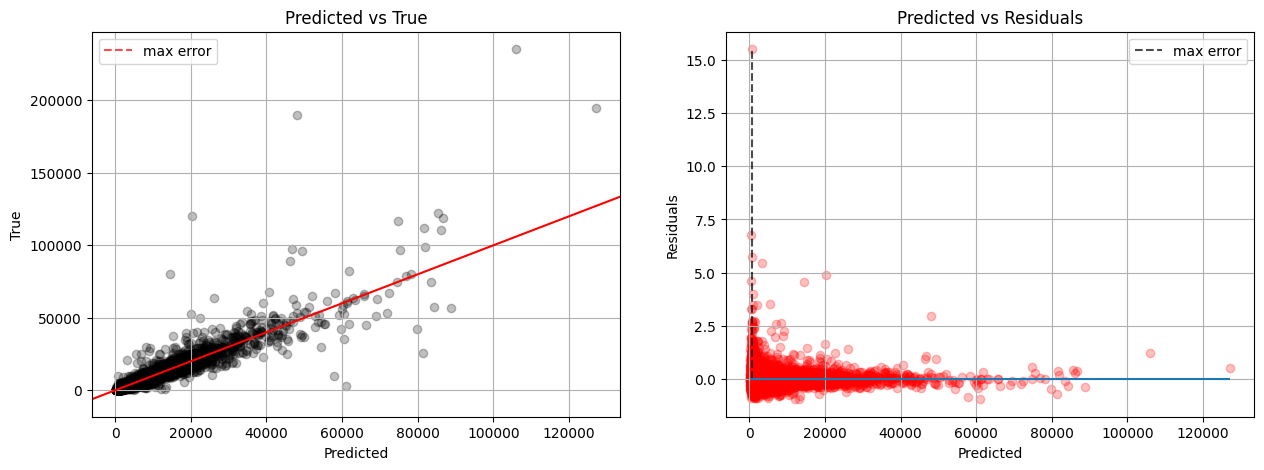

In [67]:
plot_2_error(y_test, model2.predict(X_test))

Max Error: 11
 
----------------------
   MAPE Error: 28.14
----------------------


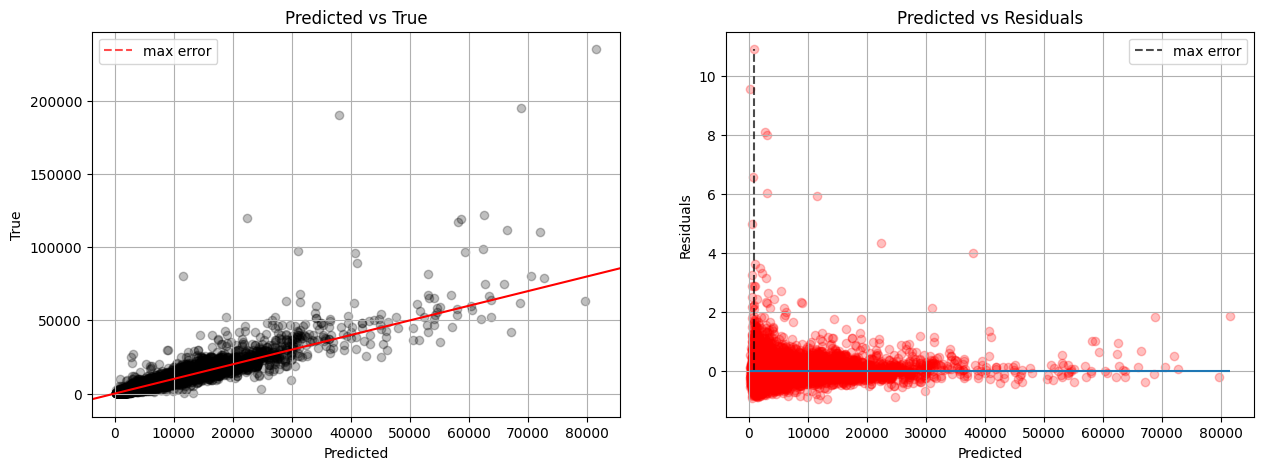

In [68]:
plot_2_error(y_test, model3.predict(X_test))

Max Error: 14
 
----------------------
   MAPE Error: 29.79
----------------------


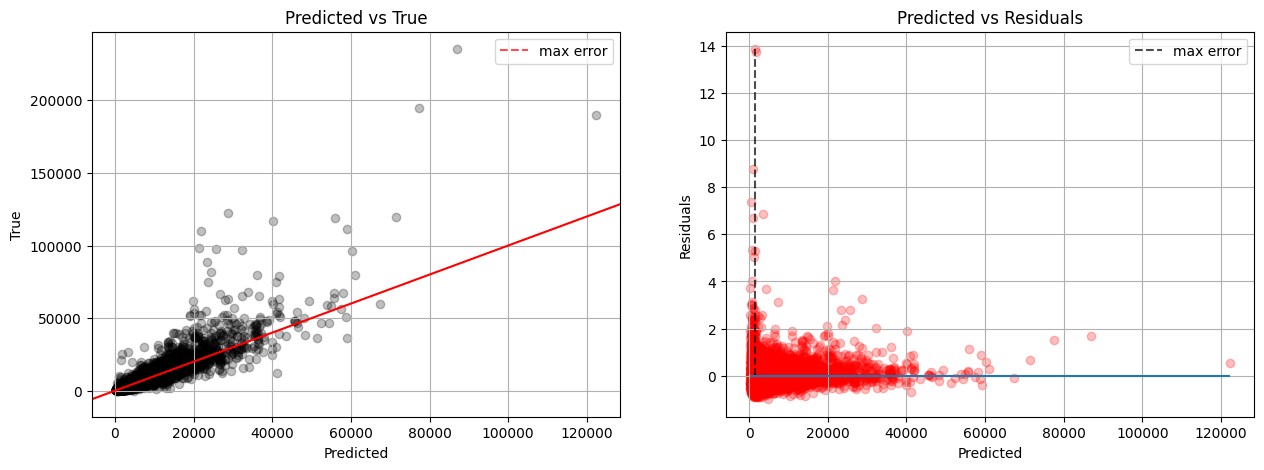

In [69]:
plot_2_error(y_test, model4.predict(X_test))

Max Error: 11
 
----------------------
   MAPE Error: 23.11
----------------------


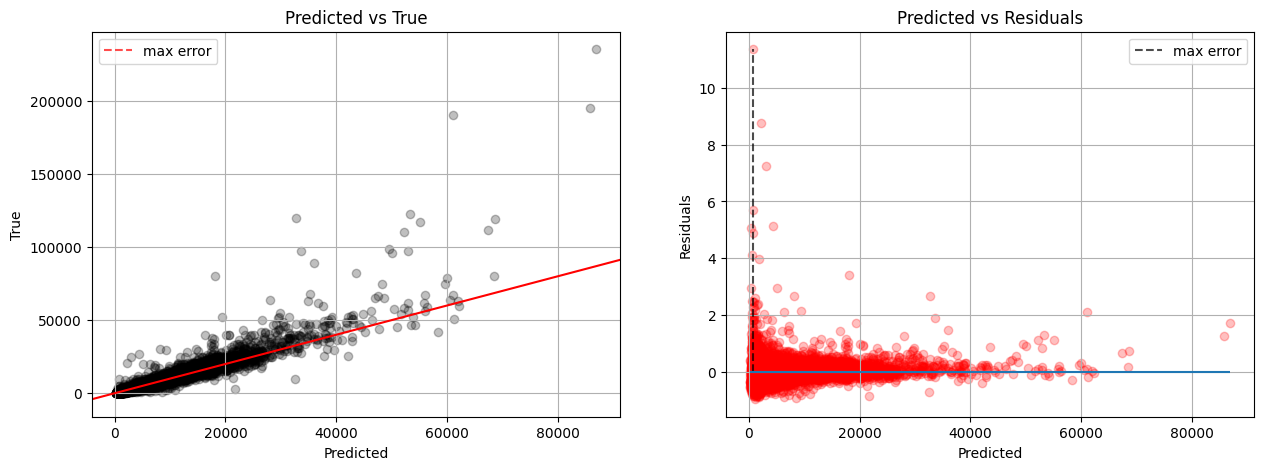

In [70]:
plot_2_error(y_test, model5.predict(X_test))

Max Error: 15
 
----------------------
   MAPE Error: 22.48
----------------------


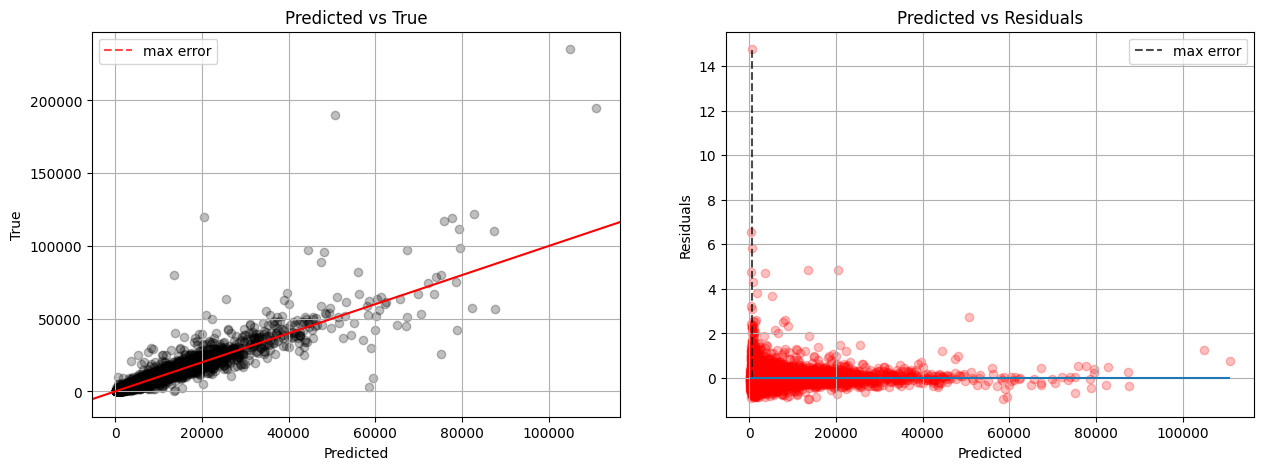

In [71]:
plot_2_error(y_test, model8.predict(X_test))

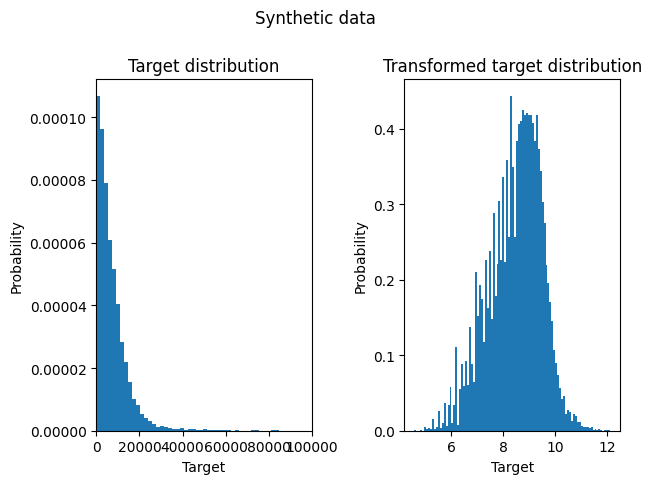

In [72]:
f, (ax0, ax1) = plt.subplots(1, 2)

ax0.hist(y_train, bins=100, density=True)
ax0.set_xlim([0, 100000])
ax0.set_ylabel("Probability")
ax0.set_xlabel("Target")
ax0.set_title("Target distribution")

y_trans = np.log1p(y_train)
ax1.hist(y_trans, bins=100, density=True)
ax1.set_ylabel("Probability")
ax1.set_xlabel("Target")
ax1.set_title("Transformed target distribution")

f.suptitle("Synthetic data", y=1)
plt.tight_layout()